# Restaurant Feature Engineering 

### Objective

The objective of restaurant feature engineering is to create a reliable
restaurant-level score that can be used to represent restaurant popularity
during synthetic order generation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_1 = pd.read_csv('cleaned_restuarants.csv')
df_1.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Buffet,Banashankari


In [5]:
df = df_1.drop(columns = ['dish_liked', 'reviews_list'])
df.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


## Info

In [171]:
df.shape

(51099, 12)

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51099 entries, 0 to 51098
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      51099 non-null  object 
 1   name                         51099 non-null  object 
 2   online_order                 51099 non-null  int64  
 3   book_table                   51099 non-null  int64  
 4   rate                         41233 non-null  float64
 5   votes                        51099 non-null  int64  
 6   location                     51099 non-null  object 
 7   rest_type                    51099 non-null  object 
 8   cuisines                     51099 non-null  object 
 9   approx_cost(for two people)  51099 non-null  int64  
 10  listed_in(type)              51099 non-null  object 
 11  listed_in(city)              51099 non-null  object 
dtypes: float64(1), int64(4), object(7)
memory usage: 4.7+ MB


In [173]:
df.describe()

,online_order,book_table,rate,votes,approx_cost(for two people)
count,51099.000000,51099.000000,41233.000000,51099.000000,51099.000000
mean,0.592379,0.126049,3.702044,285.081743,556.076929
std,0.491397,0.331908,0.440041,806.822475,439.610581
min,0.000000,0.000000,1.800000,0.000000,40.000000
25%,0.000000,0.000000,3.400000,7.000000,300.000000
50%,1.000000,0.000000,3.700000,41.000000,400.000000
75%,1.000000,0.000000,4.000000,200.000000,700.000000
max,1.000000,1.000000,4.900000,16832.000000,6000.000000


In [174]:
df.isnull().sum()

address                           0
name                              0
online_order                      0
book_table                        0
rate                           9866
votes                             0
location                          0
rest_type                         0
cuisines                          0
approx_cost(for two people)       0
listed_in(type)                   0
listed_in(city)                   0
dtype: int64

## Popularity score

In [6]:
df.head(1)

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari


### Normalising Rating and Votes

In [7]:
# calculating polpularity score via normalisation

from sklearn.preprocessing import MinMaxScaler

# normalisation via formula

def min_max_scaler(series):
    return (series - series.min())/(series.max() - series.min())
df['normalised_votes'] = min_max_scaler(df['votes']) 
df['normalised_rating'] = min_max_scaler(df['rate'])

df.head(10)

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city),normalised_votes,normalised_rating
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari,0.046043,0.741935
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari,0.046756,0.741935
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari,0.054539,0.645161
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari,0.005228,0.612903
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari,0.009862,0.645161
5,"37, 5-1, 4th Floor, Bosco Court, Gandhi Bazaar...",Timepass Dinner,1,0,3.8,286,Basavanagudi,Casual Dining,North Indian,600,Buffet,Banashankari,0.016991,0.645161
6,"19/1, New Timberyard Layout, Beside Satellite ...",Rosewood International Hotel - Bar & Restaurant,0,0,3.6,8,Mysore Road,Casual Dining,"North Indian, South Indian, Andhra, Chinese",800,Buffet,Banashankari,0.000475,0.580645
7,"2469, 3rd Floor, 24th Cross, Opposite BDA Comp...",Onesta,1,1,4.6,2556,Banashankari,"Casual Dining, Cafe","Pizza, Cafe, Italian",600,Cafes,Banashankari,0.151854,0.903226
8,"1, 30th Main Road, 3rd Stage, Banashankari, Ba...",Penthouse Cafe,1,0,4.0,324,Banashankari,Cafe,"Cafe, Italian, Continental",700,Cafes,Banashankari,0.019249,0.709677
9,"2470, 21 Main Road, 25th Cross, Banashankari, ...",Smacznego,1,0,4.2,504,Banashankari,Cafe,"Cafe, Mexican, Italian, Momos, Beverages",550,Cafes,Banashankari,0.029943,0.774194


### Formulating Popularity score

In [8]:
df['popularity_score'] = 0.6*df['normalised_votes'] + 0.4*df['normalised_rating']

In [302]:
df.head(5)

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city),normalised_votes,normalised_rating,popularity_score
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari,0.046043,0.741935,0.324400
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari,0.046756,0.741935,0.324828
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari,0.054539,0.645161,0.290788
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari,0.005228,0.612903,0.248298
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari,0.009862,0.645161,0.263982


<Axes: xlabel='rate', ylabel='popularity_score'>

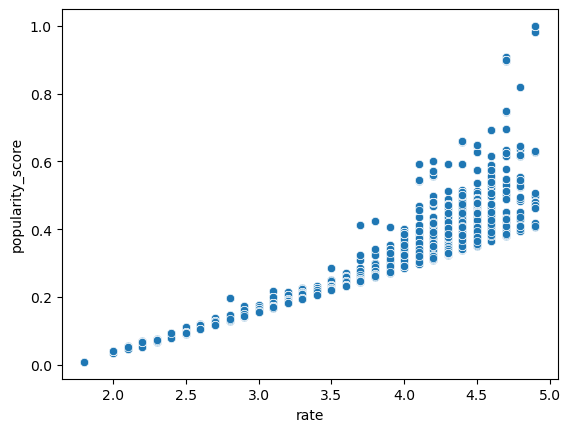

In [299]:
sns.scatterplot(df,
                x='rate',
                y='popularity_score')

<Axes: xlabel='votes', ylabel='popularity_score'>

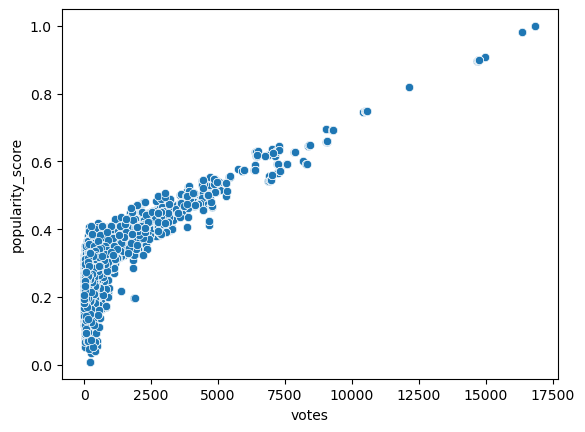

In [300]:
sns.scatterplot(df,
                x='votes',
                y='popularity_score')

In [301]:
df[['votes', 'normalised_rating', 'popularity_score']].corr()

,votes,normalised_rating,popularity_score
votes,1.000000,0.434762,0.739574
normalised_rating,0.434762,1.000000,0.927673
popularity_score,0.739574,0.927673,1.000000


**Evaluation of the Initial Popularity Score**

The resulting distribution was not well balanced, with the score being
strongly influenced by the underlying rating and rating-volume distributions.

This indicated that the initial scoring approach could be improved.

### Applying Log Transformation on Votes  and Baysian rating on rating

In [6]:
# calculating polpularity score via normalisation

from sklearn.preprocessing import MinMaxScaler

# normalisation via formula

def min_max_scaler(series):
    return (series - series.min())/(series.max() - series.min())

# log transforming the votes so that skewed data wont undermine small values

log_votes = np.log1p(df['votes'])
df['normalized_votes'] = min_max_scaler(log_votes) 

df['normalised_votes'] = min_max_scaler(df['votes']) 
df['normalised_rating'] = min_max_scaler(df['rate'])

c = df['rate'].mean()
m = df['votes'].median()

df['baysien_rating'] = (
    (df["votes"] / (df["votes"] + m)) * df["rate"].fillna(c)
    + (m / (df["votes"] + m)) * c
)

df['normalised_bayesian_rating'] = min_max_scaler(df['baysien_rating'])

# Calculating appeal score instead of popularity score ,so that i can compare both later
df['appeal_score'] = (
    0.6 * df["normalised_bayesian_rating"]
    + 0.4 * df["normalized_votes"]
)
df.head(10)

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city),normalized_votes,normalised_votes,normalised_rating,baysien_rating,normalised_bayesian_rating,appeal_score
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari,0.683803,0.046043,0.741935,4.080005,0.708592,0.698676
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari,0.685380,0.046756,0.741935,4.080294,0.708695,0.699369
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari,0.701184,0.054539,0.645161,3.795812,0.607236,0.644815
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari,0.461267,0.005228,0.612903,3.700650,0.573297,0.528485
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari,0.525942,0.009862,0.645161,3.780598,0.601810,0.571463
5,"37, 5-1, 4th Floor, Bosco Court, Gandhi Bazaar...",Timepass Dinner,1,0,3.8,286,Basavanagudi,Casual Dining,North Indian,600,Buffet,Banashankari,0.581587,0.016991,0.645161,3.787718,0.604350,0.595245
6,"19/1, New Timberyard Layout, Beside Satellite ...",Rosewood International Hotel - Bar & Restaurant,0,0,3.6,8,Mysore Road,Casual Dining,"North Indian, South Indian, Andhra, Chinese",800,Buffet,Banashankari,0.225794,0.000475,0.580645,3.685384,0.567853,0.431029
7,"2469, 3rd Floor, 24th Cross, Opposite BDA Comp...",Onesta,1,1,4.6,2556,Banashankari,"Casual Dining, Cafe","Pizza, Cafe, Italian",600,Cafes,Banashankari,0.806342,0.151854,0.903226,4.585824,0.888989,0.855930
8,"1, 30th Main Road, 3rd Stage, Banashankari, Ba...",Penthouse Cafe,1,0,4.0,324,Banashankari,Cafe,"Cafe, Italian, Continental",700,Cafes,Banashankari,0.594365,0.019249,0.709677,3.966531,0.668122,0.638619
9,"2470, 21 Main Road, 25th Cross, Banashankari, ...",Smacznego,1,0,4.2,504,Banashankari,Cafe,"Cafe, Mexican, Italian, Momos, Beverages",550,Cafes,Banashankari,0.639656,0.029943,0.774194,4.162539,0.738027,0.698679


<Axes: xlabel='votes', ylabel='appeal_score'>

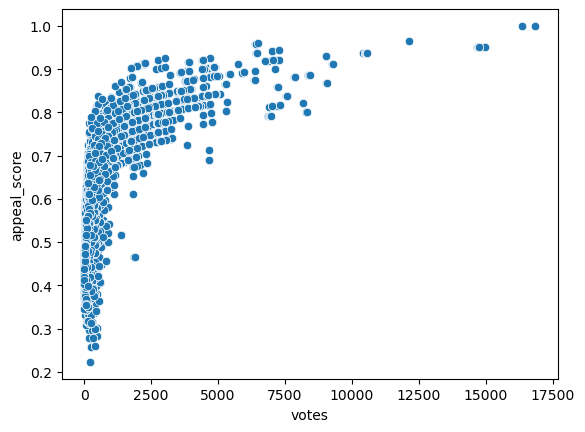

In [323]:
sns.scatterplot(df,
                x='votes',
                y='appeal_score')

<Axes: xlabel='rate', ylabel='appeal_score'>

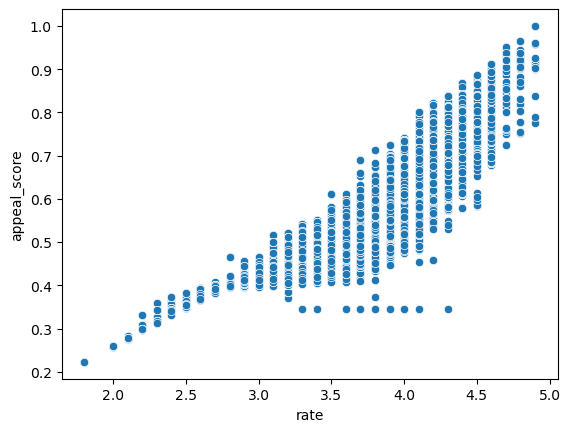

In [324]:
sns.scatterplot(df,
                x='rate',
                y='appeal_score')

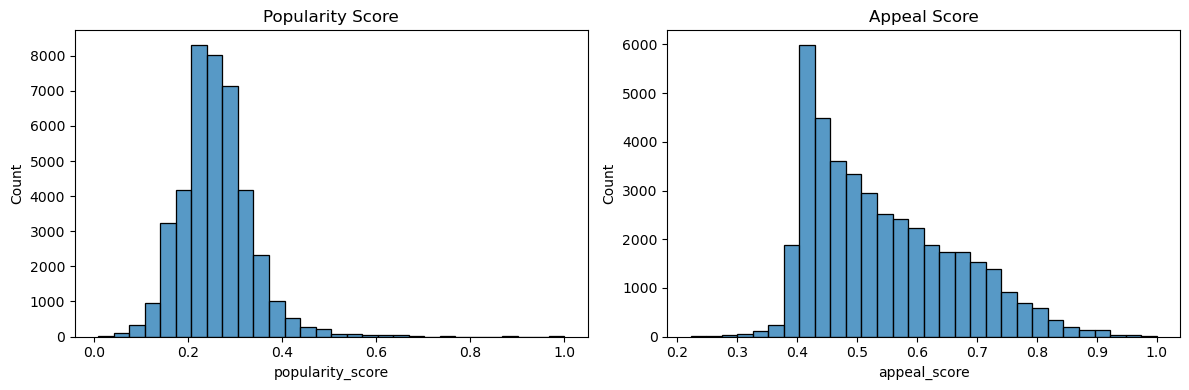

In [325]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['popularity_score'], bins=30, ax=ax[0])
ax[0].set_title("Popularity Score")

sns.histplot(df['appeal_score'], bins=30, ax=ax[1])
ax[1].set_title("Appeal Score")

plt.tight_layout()

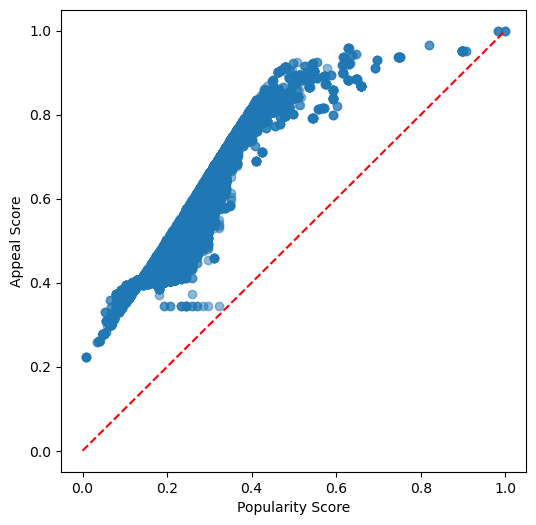

In [326]:
plt.figure(figsize=(6,6))

plt.scatter(df['popularity_score'],
            df['appeal_score'],
            alpha=0.5)

plt.xlabel("Popularity Score")
plt.ylabel("Appeal Score")
plt.plot([0,1],[0,1],'r--')

In [329]:
df[['name','rate','votes','normalized_votes','appeal_score', 'baysien_rating', 'normalised_bayesian_rating','popularity_score']].sort_values(by='appeal_score', ascending=False).head(20)

,name,rate,votes,normalized_votes,appeal_score,baysien_rating,normalised_bayesian_rating,popularity_score
49472,Byg Brewski Brewing Company,4.9,16832,1.000000,1.000000,4.897088,1.000000,1.000000
49048,Byg Brewski Brewing Company,4.9,16832,1.000000,1.000000,4.897088,1.000000,1.000000
48599,Byg Brewski Brewing Company,4.9,16832,1.000000,1.000000,4.897088,1.000000,1.000000
4907,Byg Brewski Brewing Company,4.9,16345,0.996983,0.998775,4.897002,0.999969,0.982640
4766,Byg Brewski Brewing Company,4.9,16345,0.996983,0.998775,4.897002,0.999969,0.982640
3898,Byg Brewski Brewing Company,4.9,16345,0.996983,0.998775,4.897002,0.999969,0.982640
40077,AB's - Absolute Barbecues,4.8,12121,0.966261,0.964937,4.796297,0.964054,0.819167
41076,AB's - Absolute Barbecues,4.8,12121,0.966261,0.964937,4.796297,0.964054,0.819167
36695,AB's - Absolute Barbecues,4.9,6490,0.902074,0.959843,4.892477,0.998356,0.631345
21075,AB's - Absolute Barbecues,4.9,6452,0.901471,0.959592,4.892433,0.998340,0.629990


In [331]:
df[['normalized_votes', 'normalised_bayesian_rating']].corr()

,normalized_votes,normalised_bayesian_rating
normalized_votes,1.000000,0.567932
normalised_bayesian_rating,0.567932,1.000000


In [336]:
print(df[["popularity_score", "appeal_score"]].corr())

                  popularity_score  appeal_score
popularity_score          1.000000      0.931807
appeal_score              0.931807      1.000000


In [337]:
df["pop_rank"] = df["popularity_score"].rank(ascending=False)
df["appeal_rank"] = df["appeal_score"].rank(ascending=False)

df["rank_diff"] = df["pop_rank"] - df["appeal_rank"]

df[["name","votes","rate","pop_rank","appeal_rank","rank_diff"]].sort_values(
    "rank_diff",
    key=abs,
    ascending=False
).head(20)

,name,votes,rate,pop_rank,appeal_rank,rank_diff
20994,All Aromas,0,4.3,6497.0,41033.0,-34536.0
50012,Copper Chimney,0,4.1,10496.0,41033.0,-30537.0
8201,Tangerine - Davanam Sarovar Portico Suites,0,4.0,13234.0,41033.0,-27799.0
21171,The Paratha Stories,0,3.9,16619.5,41033.0,-24413.5
21096,Nourich,0,3.9,16619.5,41033.0,-24413.5
21165,Wudfyr,0,3.8,20225.5,41033.0,-20807.5
21203,Peat & Fire,0,3.8,20225.5,41033.0,-20807.5
11132,Tasty Bites,1,3.8,20224.0,40790.0,-20566.0
8454,Chaatimes,9,4.2,8410.5,28128.5,-19718.0
22289,Chaatimes,9,4.2,8410.5,28128.5,-19718.0


In [343]:
df['appeal_v1'] = 0.6*df['normalised_rating'] + 0.4*df['normalized_votes']
df[['appeal_v1', 'appeal_score']].head(30)

,appeal_v1,appeal_score
0,0.718682,0.698676
1,0.719313,0.699369
2,0.667570,0.644817
3,0.552249,0.528465
4,0.597474,0.571452
5,0.619732,0.595240
6,0.438705,0.430968
7,0.864472,0.855930
8,0.663553,0.638615
9,0.720379,0.698676


In [344]:
df[['appeal_v1', 'appeal_score']].corr()

,appeal_v1,appeal_score
appeal_v1,1.000000,0.981225
appeal_score,0.981225,1.000000


<Axes: xlabel='appeal_score', ylabel='appeal_v1'>

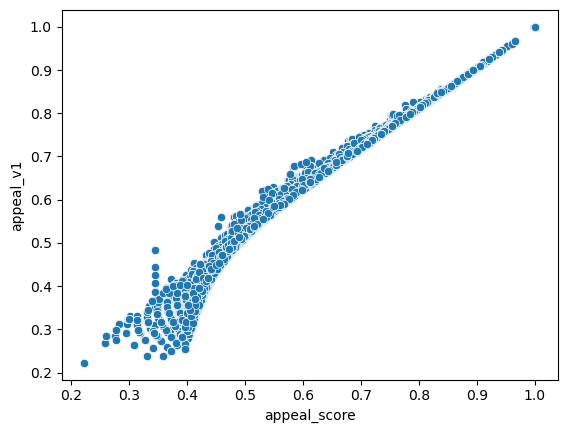

In [345]:
sns.scatterplot(df,
                y='appeal_v1',
                x='appeal_score')

In [10]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)', 'listed_in(city)', 'normalised_votes',
       'normalised_rating', 'popularity_score', 'normalized_votes',
       'baysien_rating', 'normalised_bayesian_rating', 'appeal_score'],
      dtype='object')

In [11]:
df_eda = df[['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines'
            ,'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)', 'popularity_score','appeal_score' ]]

## Price tier column

A price tier was created to categorize restaurants based on their average
price level.

This provides a simpler representation of restaurant pricing and allows
customers' price preferences to be compared with restaurant price levels
during order simulation.

In [12]:
df_eda['approx_cost(for two people)'].describe()

count    51065.000000
mean       555.687359
std        439.233910
min         40.000000
25%        300.000000
50%        400.000000
75%        700.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64

C:\Users\ahlaw\AppData\Local\Temp\ipykernel_11812\1703931040.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['approx_cost(for two people)'])


<Axes: xlabel='approx_cost(for two people)', ylabel='Density'>

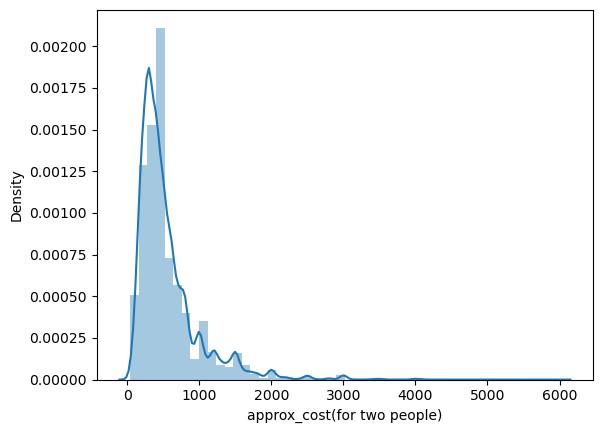

In [13]:
sns.distplot(df['approx_cost(for two people)'])

In [373]:
df['approx_cost(for two people)'].quantile([0.5, 0.85, 0.90, 0.95])

0.50     400.0
0.85     850.0
0.90    1100.0
0.95    1500.0
Name: approx_cost(for two people), dtype: float64

In [371]:
print(df["approx_cost(for two people)"].describe())
print(df["approx_cost(for two people)"].quantile([0.25, 0.5, 0.75, 0.96]))

count    51065.000000
mean       555.687359
std        439.233910
min         40.000000
25%        300.000000
50%        400.000000
75%        700.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64
0.25     300.0
0.50     400.0
0.75     700.0
0.96    1500.0
Name: approx_cost(for two people), dtype: float64


In [372]:
len(df[df["approx_cost(for two people)"] >= 1500])

2736

Price tiers were created using business-relevant cost thresholds informed by the data distribution (median, 85th percentile, and 95th percentile). This produces interpretable categories that better represent customer perception than equal-frequency bins.

In [377]:
bins = [0, 400, 850, 1500, float("inf")]
labels = ["Budget", "Mid-range", "Premium", "Luxury"]

df_eda["price_tier"] = pd.cut(
    df_eda["approx_cost(for two people)"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

C:\Users\ahlaw\AppData\Local\Temp\ipykernel_34120\1874980184.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda["price_tier"] = pd.cut(


In [14]:
df_eda = df_eda.rename(columns={'approx_cost(for two people)': 'cost'})

In [15]:
df_eda.to_csv('EDA_restaurants.csv', index= False)